# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Cargue el archivo de datos, y haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Datasets/Telco_customer_churn.csv',
    na_values=[' ']
    )

df.sample(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
750,0310-MVLET,1,United States,California,Snelling,95369,"37.521708, -120.426843",37.521708,-120.426843,Female,...,Month-to-month,Yes,Electronic check,99.15,6010.05,Yes,1,77,5612,Service dissatisfaction
5773,0774-RMNUW,1,United States,California,Pala,92059,"33.384345, -117.072619",33.384345,-117.072619,Female,...,Two year,No,Bank transfer (automatic),59.70,4122.65,No,0,63,6420,NaN
6212,9402-CXWPL,1,United States,California,Birds Landing,94512,"38.140719, -121.838298",38.140719,-121.838298,Female,...,One year,No,Electronic check,98.90,6838.60,No,0,20,5980,NaN
1428,5959-BELXA,1,United States,California,Yucaipa,92399,"34.04597, -117.011825",34.045970,-117.011825,Male,...,Month-to-month,Yes,Credit card (automatic),96.15,3019.25,Yes,1,79,2246,Price too high
6299,0020-JDNXP,1,United States,California,Point Reyes Station,94956,"38.060264, -122.830646",38.060264,-122.830646,Female,...,One year,No,Mailed check,61.25,1993.20,No,0,37,3607,NaN


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [12]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [13]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3186-AJIEK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [14]:
df = df.drop(columns=['Count', 'CustomerID', 'Country', 'State', 'Lat Long',
             'Churn Value', 'Churn Reason'])

Variables nominales: 'City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup','Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',  'Paperless Billing', 'Payment Method', 'Churn Label'

Variables ordinales: 'Contract'

Variables de alta cardinalidad: 'City'

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Reporte los resultados del análisis en una celda de texto.

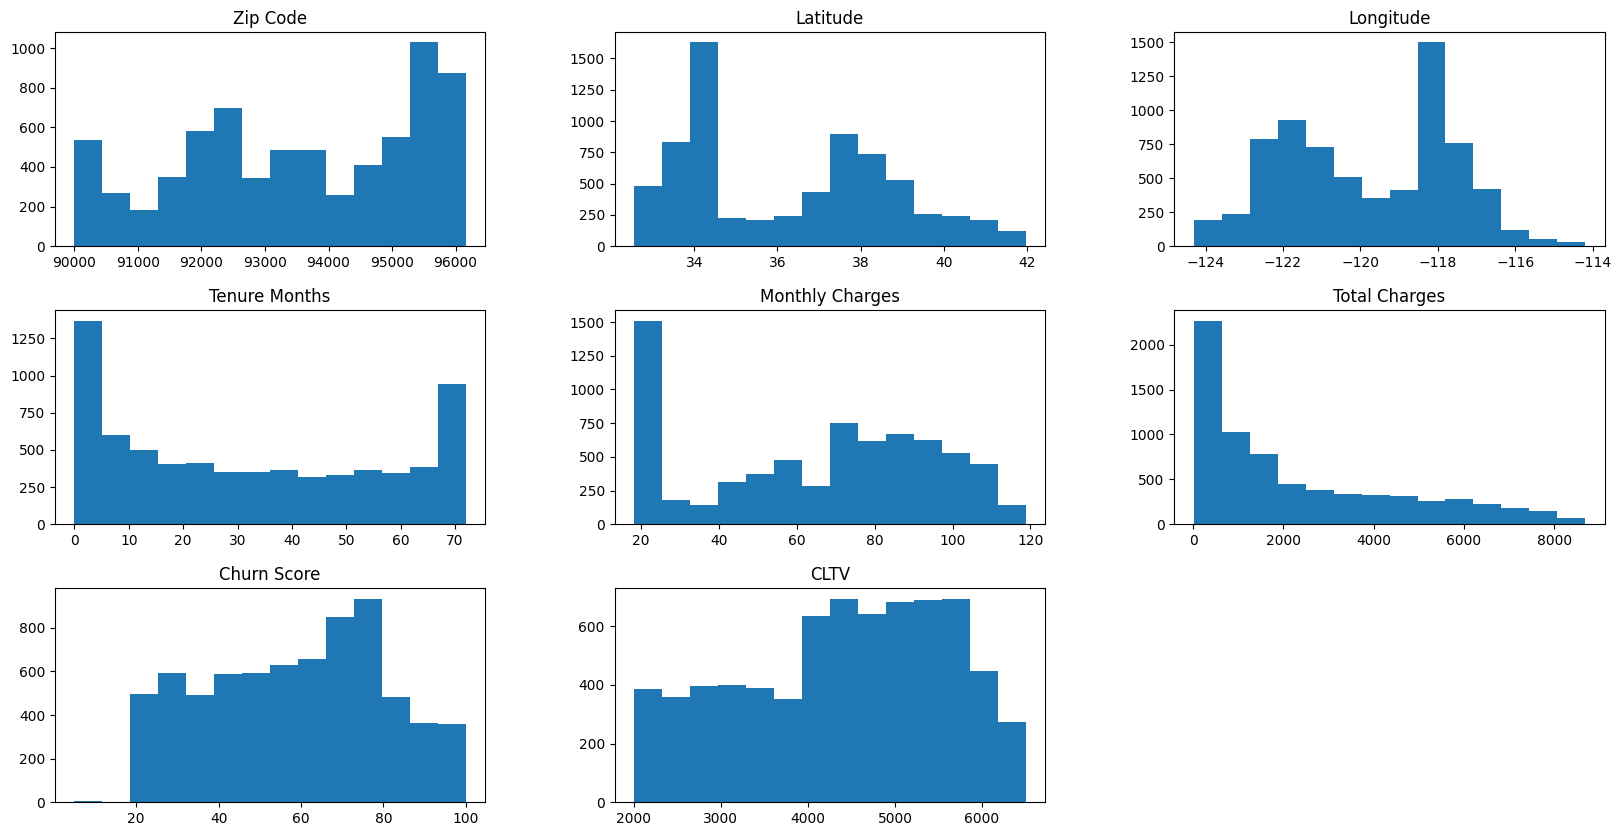

In [15]:
df.hist(figsize=(20, 10), bins='sturges', grid=False);

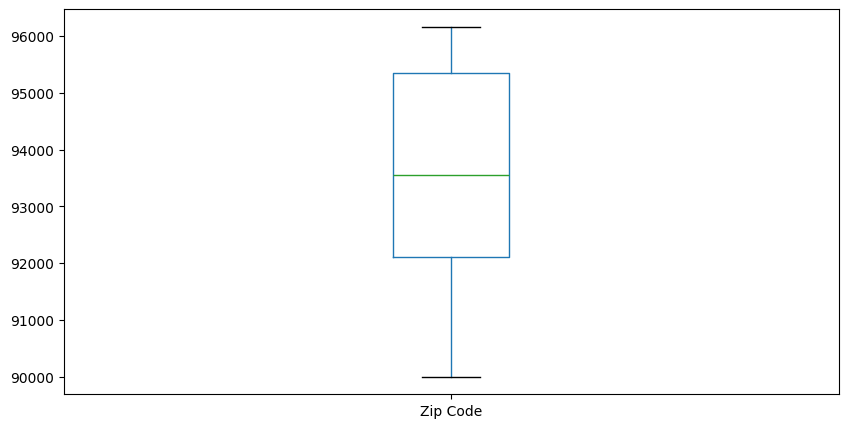

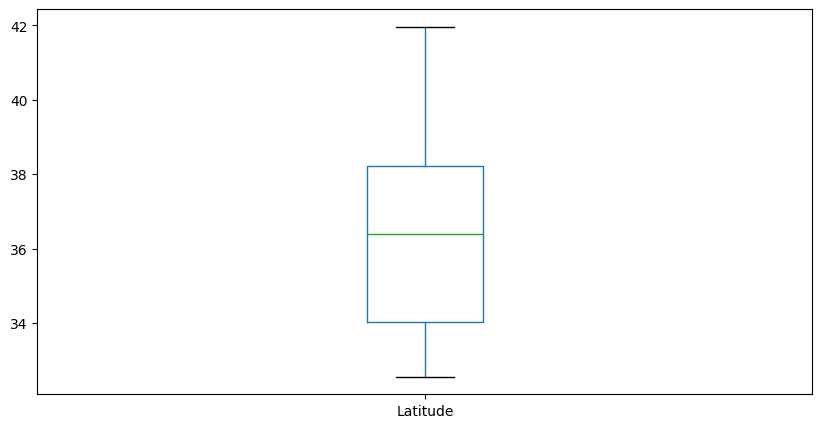

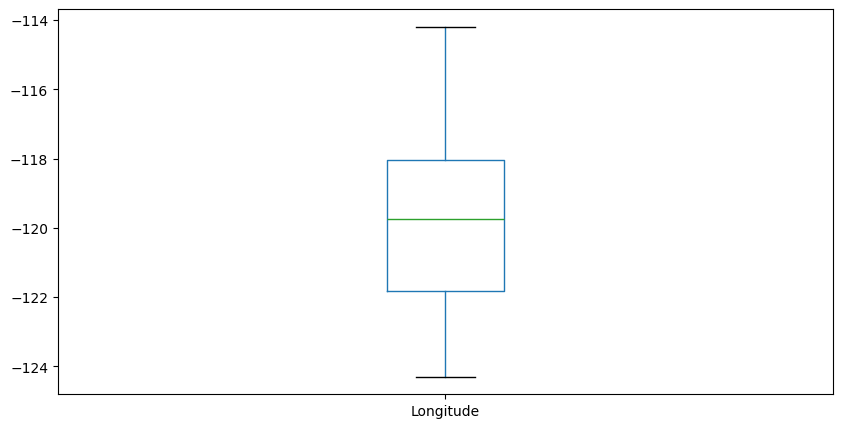

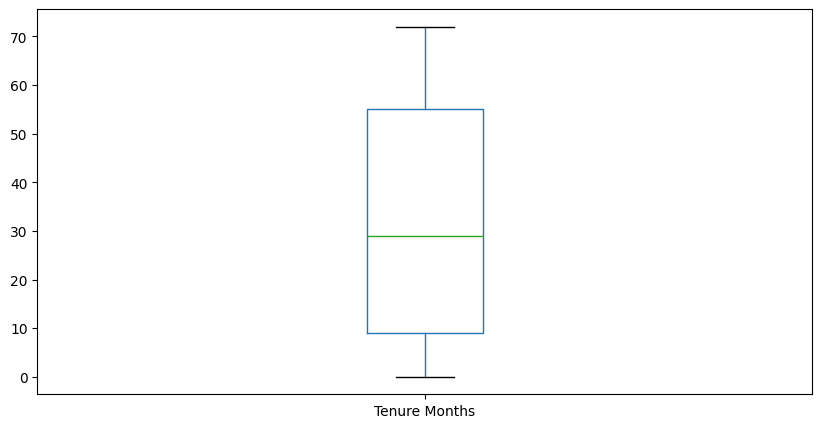

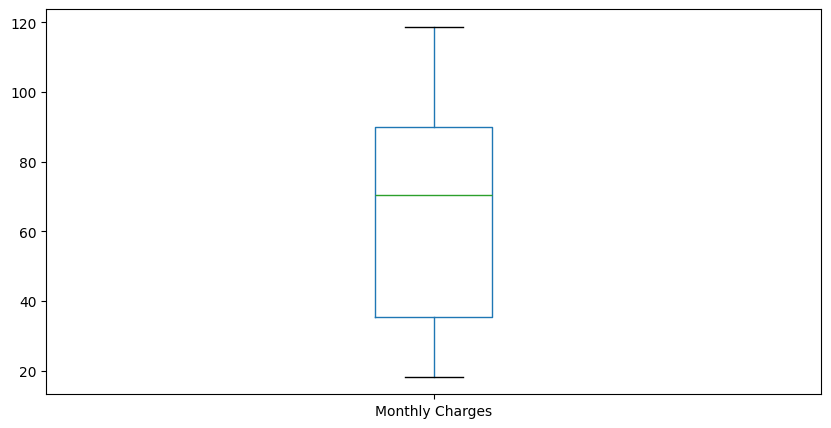

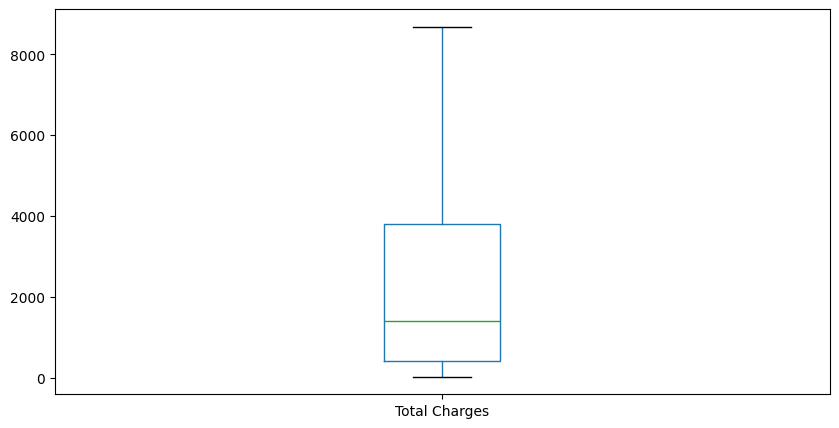

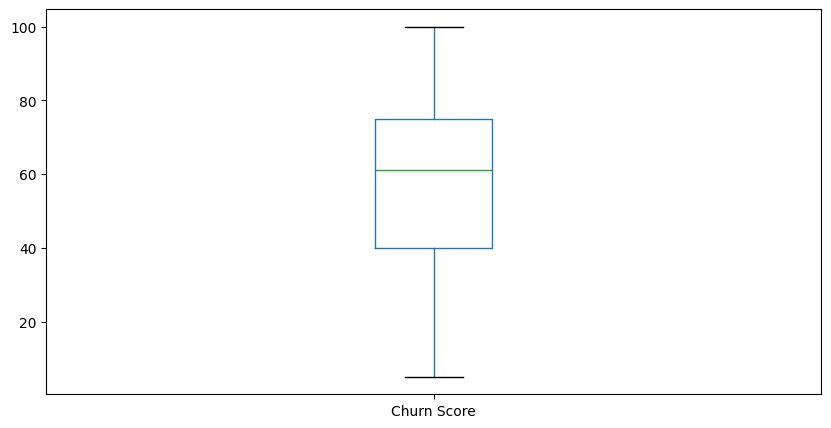

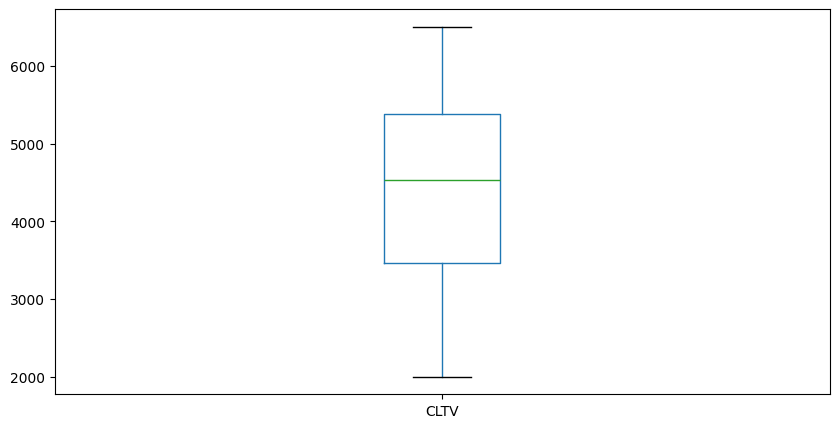

In [21]:
import matplotlib.pyplot as plt

num_vars = df.select_dtypes(include='number').columns.to_list()
for var in num_vars:
  plt.figure(figsize=(10, 5))
  df.boxplot(column=var, grid=False)
  plt.show()

Ninguna de las variables es normal, ni de manera aproximada.

Ninguna tiene valores atípicos.

<Figure size 640x480 with 0 Axes>

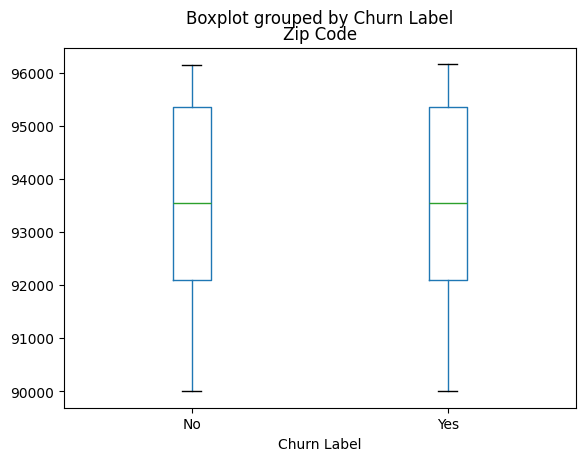

<Figure size 640x480 with 0 Axes>

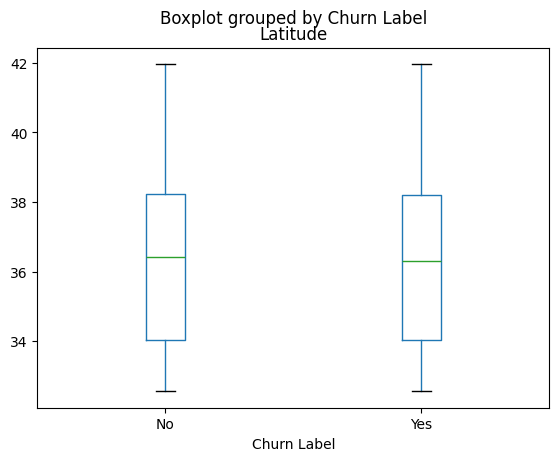

<Figure size 640x480 with 0 Axes>

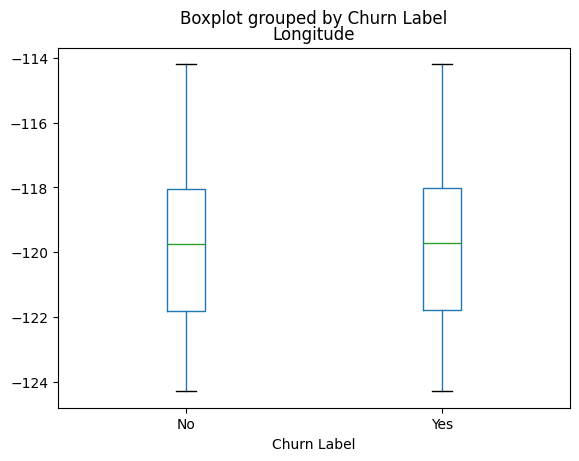

<Figure size 640x480 with 0 Axes>

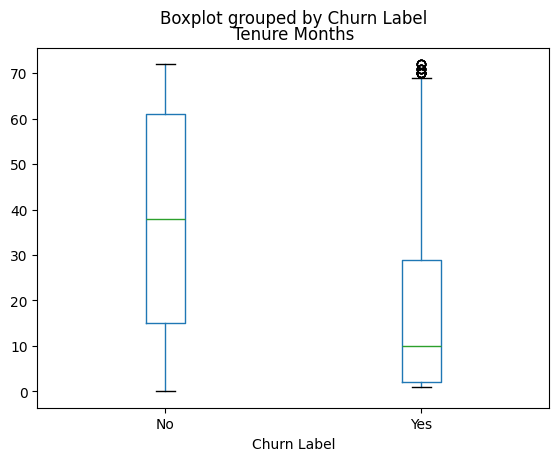

<Figure size 640x480 with 0 Axes>

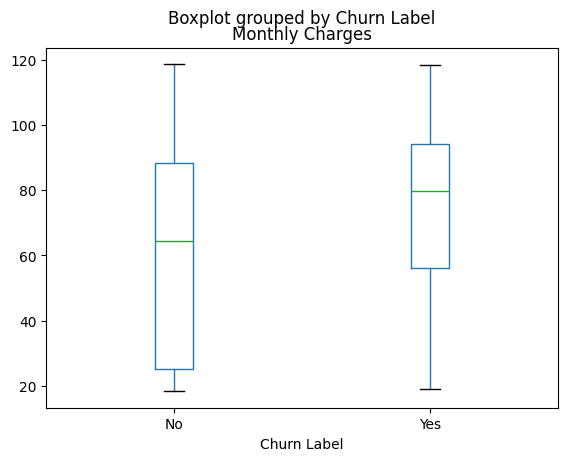

<Figure size 640x480 with 0 Axes>

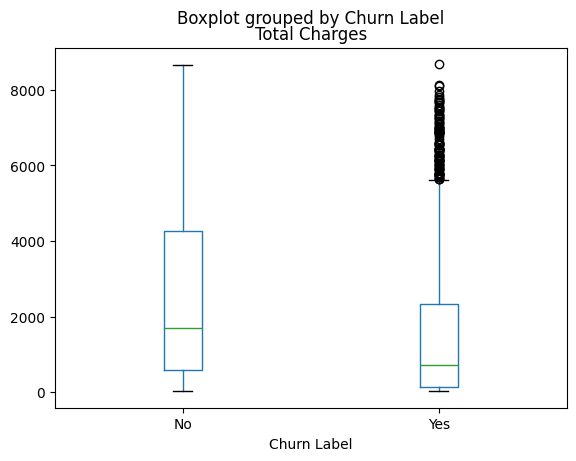

<Figure size 640x480 with 0 Axes>

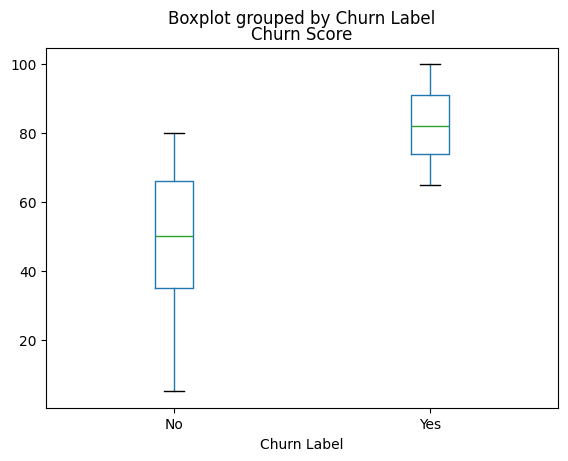

<Figure size 640x480 with 0 Axes>

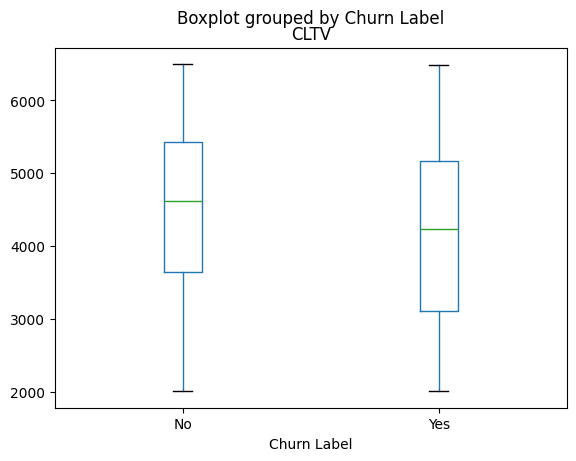

In [22]:
for var in num_vars:
  plt.figure()
  df.boxplot(column=var, grid=False, by='Churn Label')
  plt.show()


Posibles buenas predictoras: 'Churn score', 'Tenure Months', 'Monthly Charges', 'Total Charges'.

<Figure size 1000x500 with 0 Axes>

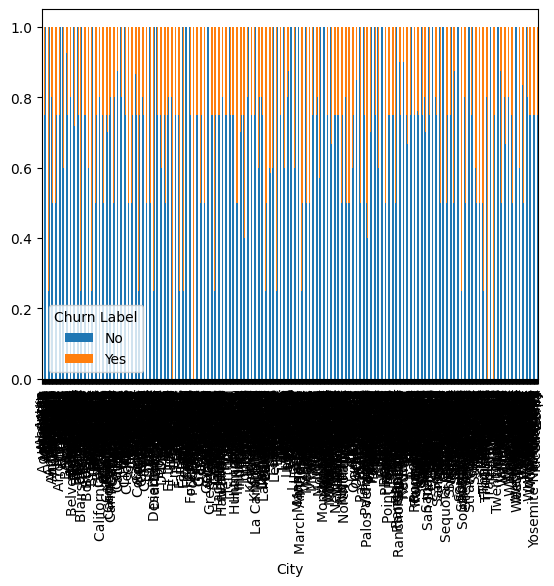

<Figure size 1000x500 with 0 Axes>

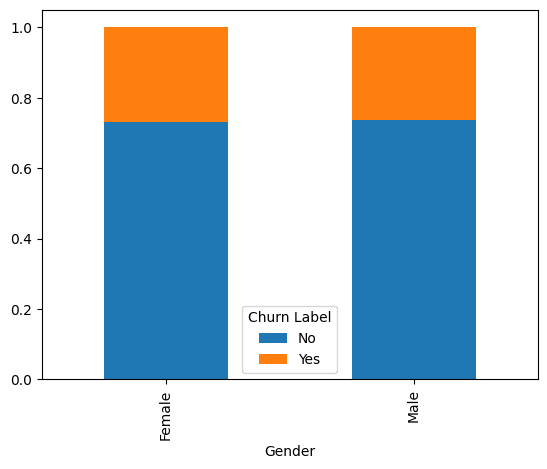

<Figure size 1000x500 with 0 Axes>

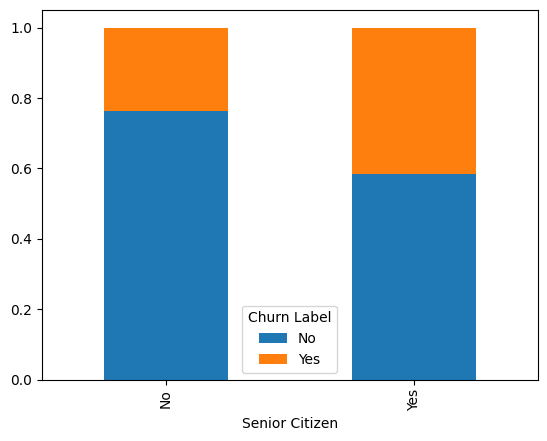

<Figure size 1000x500 with 0 Axes>

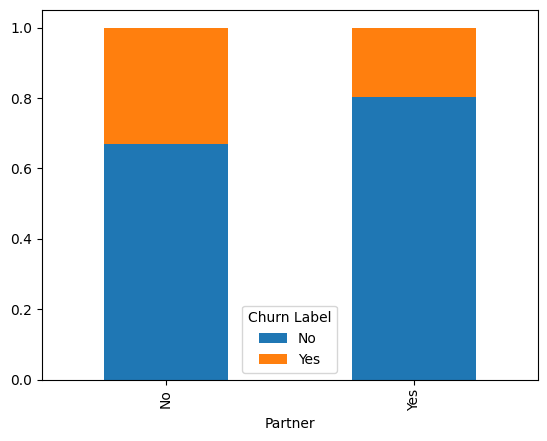

<Figure size 1000x500 with 0 Axes>

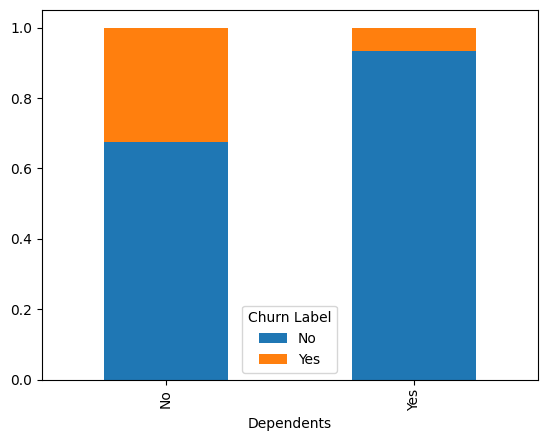

<Figure size 1000x500 with 0 Axes>

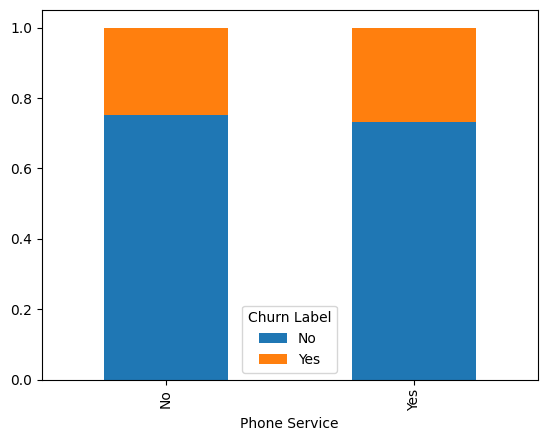

<Figure size 1000x500 with 0 Axes>

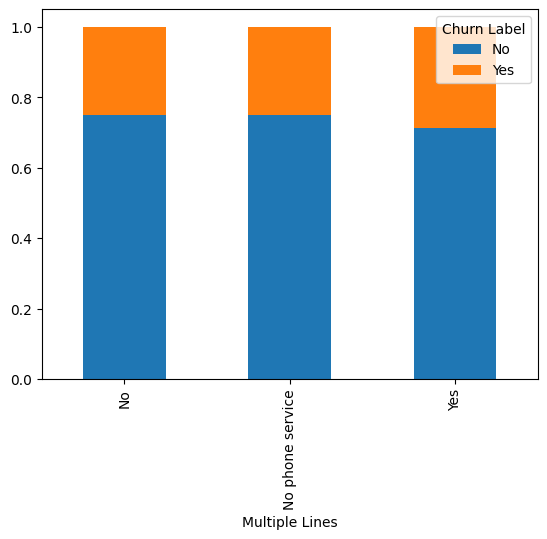

<Figure size 1000x500 with 0 Axes>

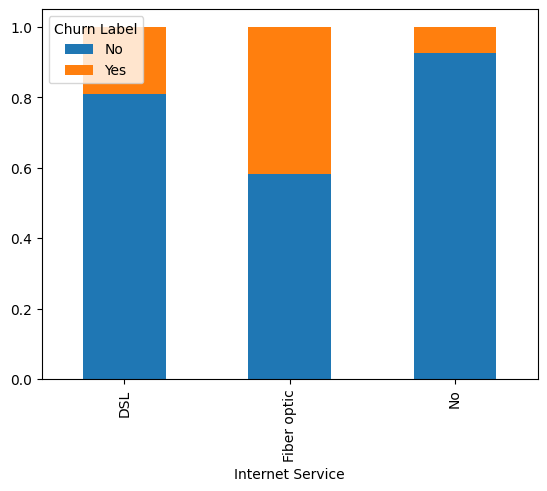

<Figure size 1000x500 with 0 Axes>

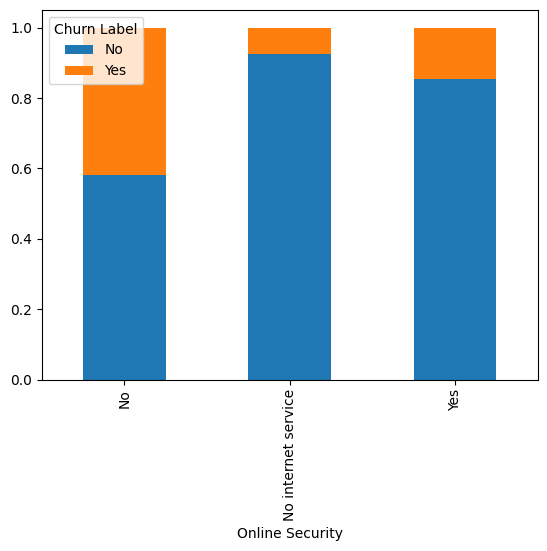

<Figure size 1000x500 with 0 Axes>

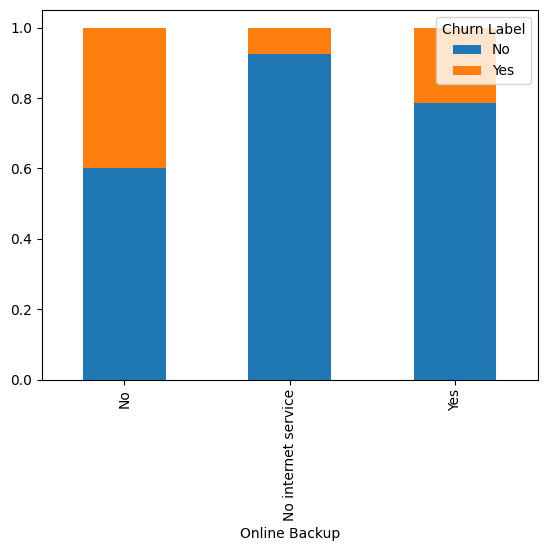

<Figure size 1000x500 with 0 Axes>

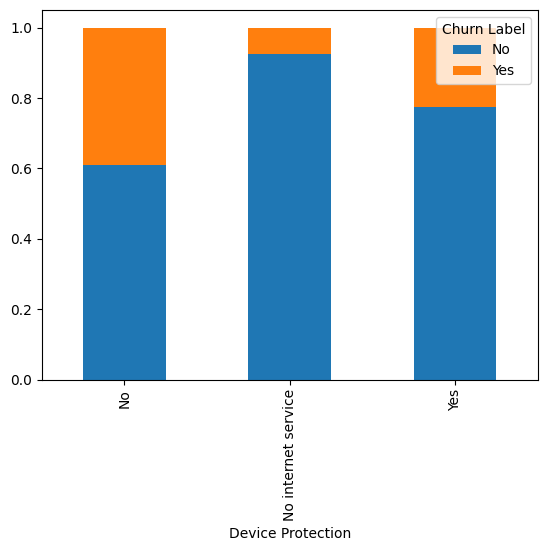

<Figure size 1000x500 with 0 Axes>

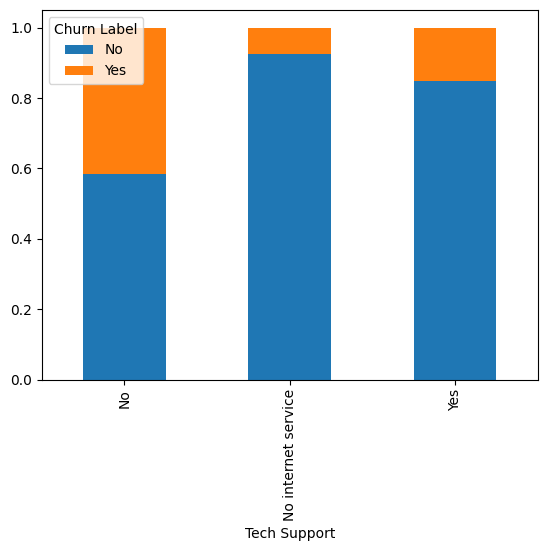

<Figure size 1000x500 with 0 Axes>

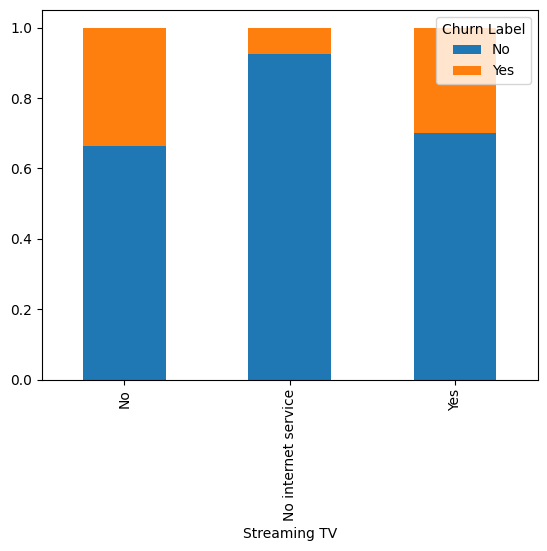

<Figure size 1000x500 with 0 Axes>

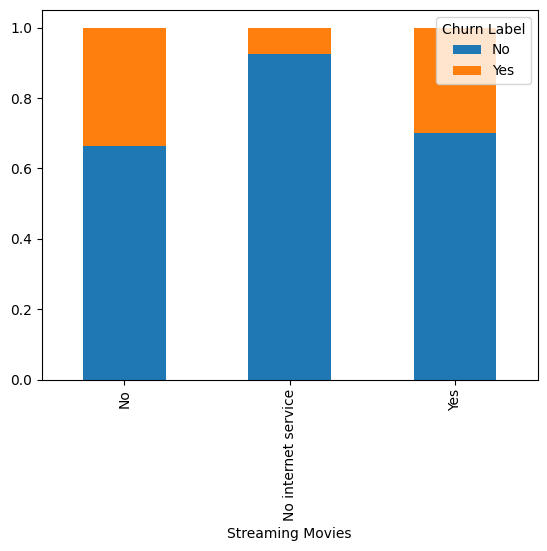

<Figure size 1000x500 with 0 Axes>

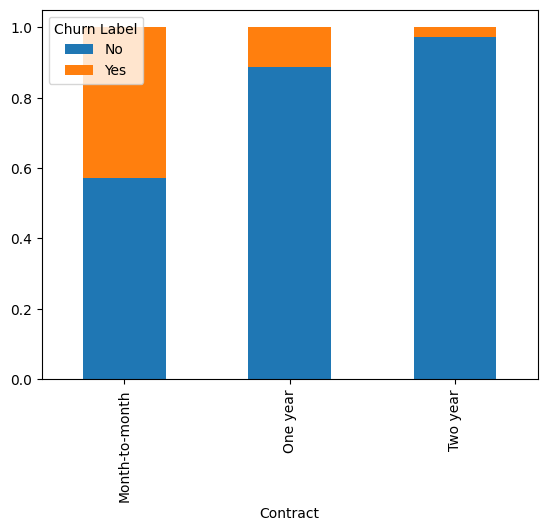

<Figure size 1000x500 with 0 Axes>

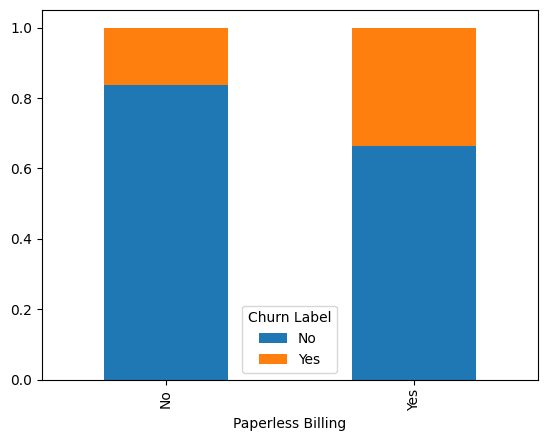

<Figure size 1000x500 with 0 Axes>

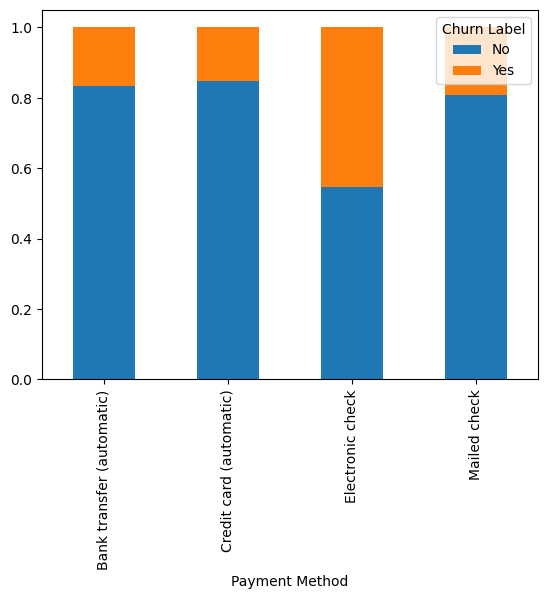

In [23]:
from numpy.random.mtrand import normal
cat_vars = df.drop(columns=['Churn Label']).select_dtypes(include='object').columns.to_list()

for var in cat_vars:
  table = pd.crosstab(df[var], df['Churn Label'], normalize='index')
  plt.figure(figsize=(10, 5))
  table.plot(kind='bar', stacked=True)
  plt.show()

Posibles buenas predictoras: 'Contract', 'Senior Citizen', 'Partner, 'Dependents', 'Payment Method', 'Paperless Billing', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Churn Label**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 6 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 6 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn Label'])
y = df['Churn Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 25)
(1409, 25)
(5634,)
(1409,)


Primeras 6 características seleccionadas:
- Contract: OrdinalEncoder
- Dependents: OneHotEncoder
- Online Security: OneHotEncoder
- Churn Score: MinMaxScaler
- Tenure Months: MinMaxScaler
- Senior Citizen: OneHotEncoder

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
oe = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
mm = MinMaxScaler()

preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Dependents', 'Online Security', 'Senior Citizen']),
    ('oe', oe, ['Contract']),
    ('mm', mm, ['Churn Score', 'Tenure Months'])
    ],
    remainder='drop')

preprocessor

ColumnTransformer(transformers=[('ohe',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Dependents', 'Online Security',
                                  'Senior Citizen']),
                                ('oe',
                                 OrdinalEncoder(categories=[['Month-to-month',
                                                             'One year',
                                                             'Two year']]),
                                 ['Contract']),
                                ('mm', MinMaxScaler(),
                                 ['Churn Score', 'Tenure Months'])])

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = LogisticRegression(max_iter=10000)

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Dependents',
                                                   'Online Security',
                                                   'Senior Citizen']),
                                                 ('oe',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('mm', MinMaxScaler(),
                                                  ['Churn Score',
                                                   'Tenure Months'])])),
                ('clf', LogisticRegression(max_iter=10000))])

In [31]:
model.fit(X_train, y_train)

print(f'Score de entrenamiento: {model.score(X_train, y_train)}')
print(f'Score de prueba: {model.score(X_test, y_test)}')

Score de entrenamiento: 0.916222932197373
Score de prueba: 0.9127040454222853


In [32]:
model.named_steps['preprocessor'].get_feature_names_out()

array(['ohe__Dependents_Yes', 'ohe__Online Security_No',
       'ohe__Online Security_No internet service',
       'ohe__Online Security_Yes', 'ohe__Senior Citizen_Yes',
       'oe__Contract', 'mm__Churn Score', 'mm__Tenure Months'],
      dtype=object)

Vuelva a entrenar el modelo, pero esta vez añada 3 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Nuevas características:
- Payment Method: OneHotEncoder
- Internet Service: OneHotEncoder
- Monthly Charges: MinMaxScaler

In [33]:
preprocessor = ColumnTransformer(transformers=[
    ('ohe', ohe, ['Dependents', 'Online Security', 'Senior Citizen', 'Payment Method', 'Internet Service']),
    ('oe', oe, ['Contract']),
    ('mm', mm, ['Churn Score', 'Tenure Months', 'Monthly Charges'])
    ],
    remainder='drop')

model = Pipeline([
    ('preprocessor', preprocessor),
     ('clf', clf)
    ])

model.fit(X_train, y_train)

print(f'Score de entrenamiento: {model.score(X_train, y_train)}')
print(f'Score de prueba: {model.score(X_test, y_test)}')

Score de entrenamiento: 0.9226127085552006
Score de prueba: 0.9169623846699787


In [34]:
model.named_steps['preprocessor'].get_feature_names_out()

array(['ohe__Dependents_Yes', 'ohe__Online Security_No',
       'ohe__Online Security_No internet service',
       'ohe__Online Security_Yes', 'ohe__Senior Citizen_Yes',
       'ohe__Payment Method_Bank transfer (automatic)',
       'ohe__Payment Method_Credit card (automatic)',
       'ohe__Payment Method_Electronic check',
       'ohe__Payment Method_Mailed check', 'ohe__Internet Service_DSL',
       'ohe__Internet Service_Fiber optic', 'ohe__Internet Service_No',
       'oe__Contract', 'mm__Churn Score', 'mm__Tenure Months',
       'mm__Monthly Charges'], dtype=object)